In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.abspath('../parameter_scan'))

import numpy as np
import pandas as pd
import cariaco_obs

# Raw CSV — sees columns the loader strips
df = pd.read_csv(cariaco_obs.DEFAULT_CSV_PATH)
df["_date"] = pd.to_datetime(df["date"])

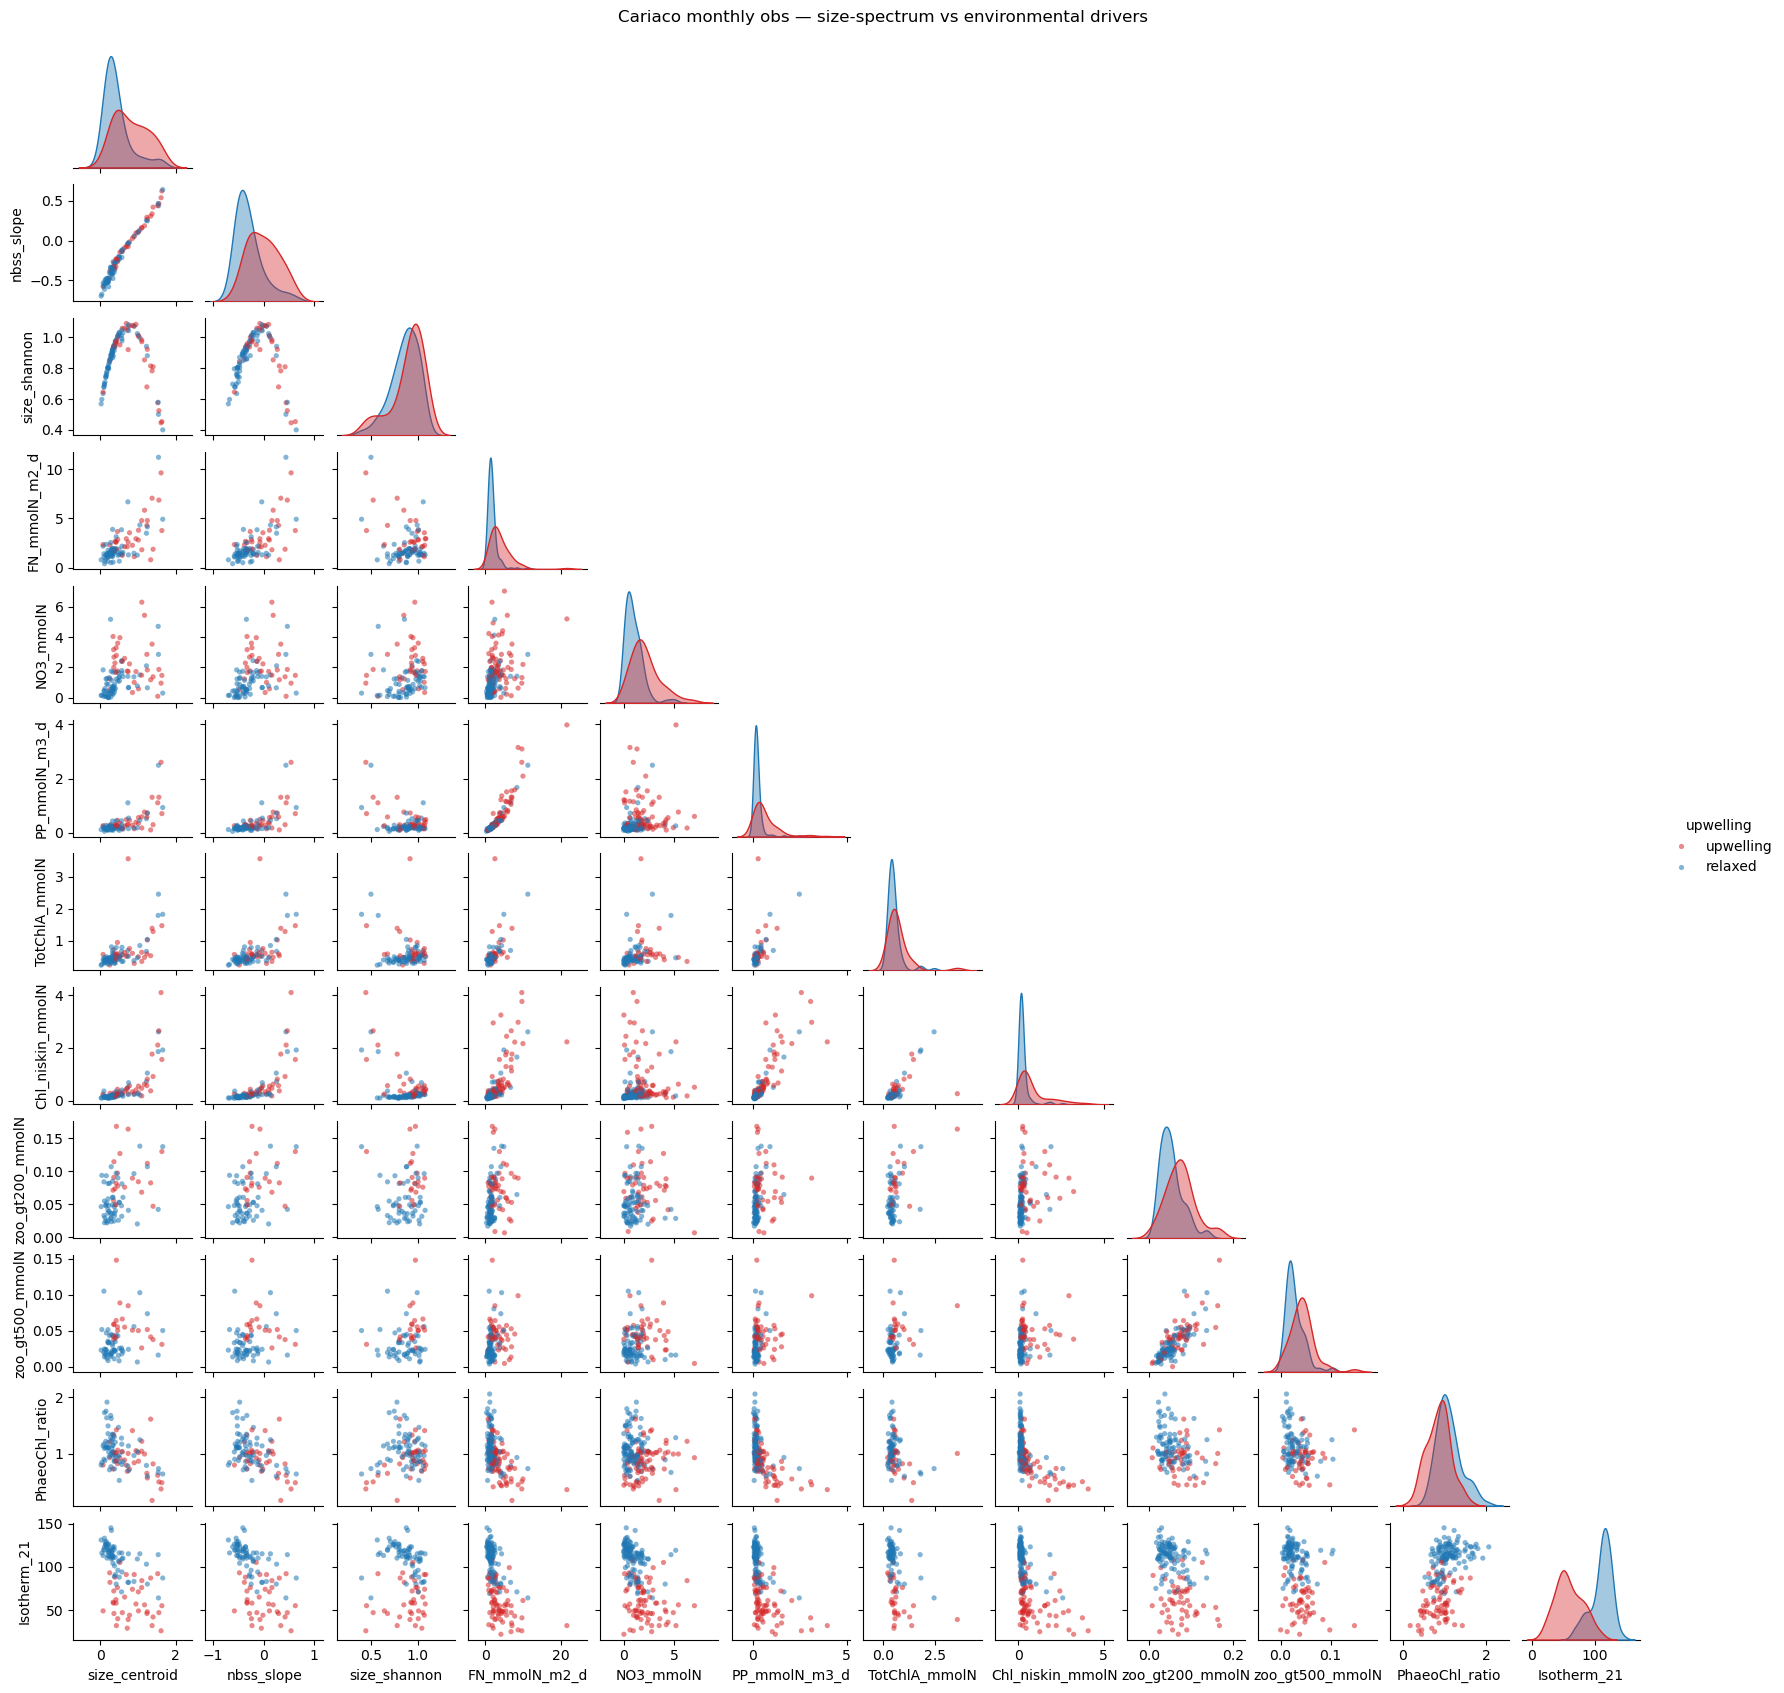

In [2]:
# --- Cell: Pair-plot overview ---
import seaborn as sns
import matplotlib.pyplot as plt

PAIRS_VARS = [
    # Size-spectrum metrics
    "size_centroid", "nbss_slope", "size_shannon",
    # Bottom-up forcing
    "FN_mmolN_m2_d", "NO3_mmolN",
    # Productivity / Chl
    "PP_mmolN_m3_d", "TotChlA_mmolN", "Chl_niskin_mmolN",
    # Top-down
    "zoo_gt200_mmolN", "zoo_gt500_mmolN", "PhaeoChl_ratio",
    # Physical
    "Isotherm_21",
]

sub = df[PAIRS_VARS + ["upwelling"]].copy()

g = sns.pairplot(
    sub,
    vars=PAIRS_VARS,
    hue="upwelling",
    hue_order=["upwelling", "relaxed"],
    palette={"upwelling": "#d62728", "relaxed": "#1f77b4"},
    diag_kind="kde",
    plot_kws=dict(s=14, alpha=0.55, edgecolor="none"),
    diag_kws=dict(common_norm=False, fill=True, alpha=0.4),
    height=1.4,
    corner=True
)
g.figure.suptitle("Cariaco monthly obs — size-spectrum vs environmental drivers",
                  y=1.01, fontsize=12)
plt.show()

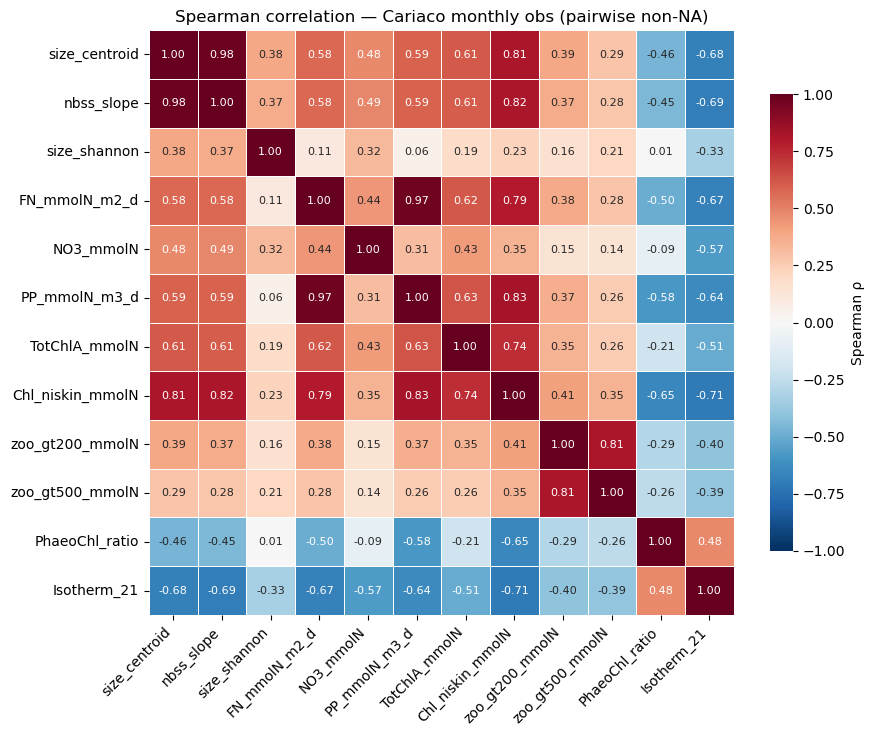

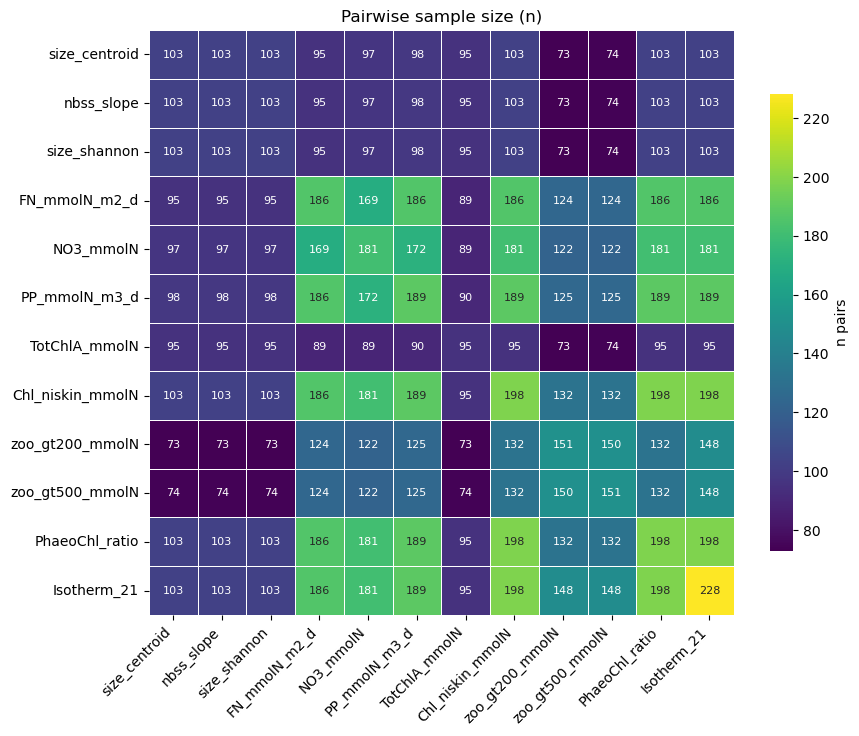

In [6]:
# --- Cell: Correlation heatmap (Spearman, pairwise non-NA) ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = sub[PAIRS_VARS].corr(method="spearman")
n_pairs = (sub[PAIRS_VARS].notna().astype(int).T
           @ sub[PAIRS_VARS].notna().astype(int))

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws=dict(size=8),
    square=True,
    linewidths=0.5, linecolor="white",
    cbar_kws=dict(shrink=0.75, label="Spearman ρ"),
    ax=ax,
)
ax.set_title("Spearman correlation — Cariaco monthly obs (pairwise non-NA)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Sample-size matrix as a companion (so you know which ρ values are 95-point vs 73-point)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    n_pairs,
    cmap="viridis",
    annot=True, fmt="d",
    annot_kws=dict(size=8),
    square=True,
    linewidths=0.5, linecolor="white",
    cbar_kws=dict(shrink=0.75, label="n pairs"),
    ax=ax,
)
ax.set_title("Pairwise sample size (n)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

n points: 95


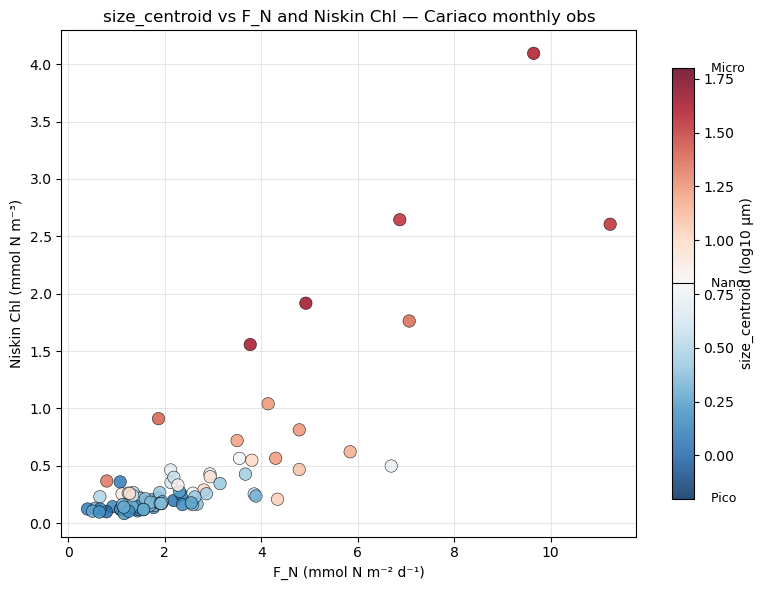

In [7]:
# --- Cell: Centroid coloured against F_N × Niskin Chl ---
import numpy as np
import matplotlib.pyplot as plt

# Reference points on the centroid colour axis
PICO_LOG  = np.log10(0.63)   # ≈ -0.20  Pico-geomean
NANO_LOG  = np.log10(6.3)    # ≈ +0.80  Nano-geomean
MICRO_LOG = np.log10(63)     # ≈ +1.80  Micro-geomean

m = (sub["FN_mmolN_m2_d"].notna()
     & sub["Chl_niskin_mmolN"].notna()
     & sub["size_centroid"].notna())
print(f"n points: {m.sum()}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    sub.loc[m, "FN_mmolN_m2_d"],
    sub.loc[m, "Chl_niskin_mmolN"],
    c=sub.loc[m, "size_centroid"],
    cmap="RdBu_r",
    vmin=PICO_LOG, vmax=MICRO_LOG, # symmetric-ish around the Nano midpoint
    s=80, edgecolor="black", linewidth=0.4, alpha=0.85,
)
ax.set_xlabel("F_N (mmol N m⁻² d⁻¹)")
ax.set_ylabel("Niskin Chl (mmol N m⁻³)")
ax.set_title("size_centroid vs F_N and Niskin Chl — Cariaco monthly obs")
ax.grid(alpha=0.3)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("size_centroid (log10 µm)")
# Mark the three geomean lines on the colourbar so the colour is interpretable
for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    cbar.ax.axhline(y, color="black", lw=0.8, ls=ls)
    cbar.ax.text(1.6, y, f" {lbl}", va="center", fontsize=9,
                 transform=cbar.ax.get_yaxis_transform())

plt.tight_layout()
plt.show()

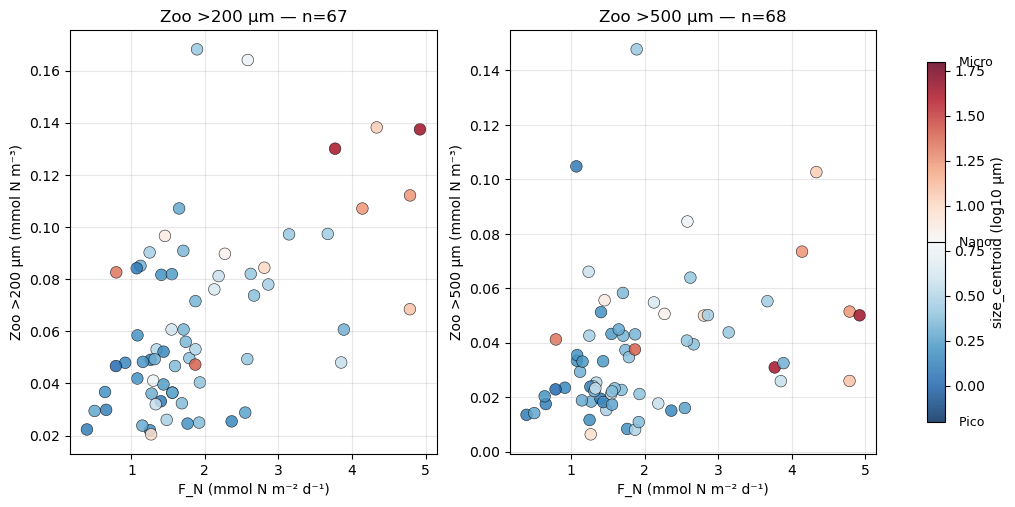

In [9]:
# --- Cell: Zoo biomass vs F_N, coloured by size_centroid ---
import numpy as np
import matplotlib.pyplot as plt

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
for ax, zoo_col, label in [(axes[0], "zoo_gt200_mmolN", "Zoo >200 µm"),
                            (axes[1], "zoo_gt500_mmolN", "Zoo >500 µm")]:
    m = (df["FN_mmolN_m2_d"].notna()
         & df[zoo_col].notna()
         & df["size_centroid"].notna())
    sc = ax.scatter(df.loc[m, "FN_mmolN_m2_d"],
                    df.loc[m, zoo_col],
                    c=df.loc[m, "size_centroid"],
                    cmap="RdBu_r",
                    vmin=PICO_LOG, vmax=MICRO_LOG,
                    s=70, edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.set_xlabel("F_N (mmol N m⁻² d⁻¹)")
    ax.set_ylabel(f"{label} (mmol N m⁻³)")
    ax.set_title(f"{label} — n={m.sum()}")
    ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=axes, shrink=0.85)
cbar.set_label("size_centroid (log10 µm)")
for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    cbar.ax.axhline(y, color="black", lw=0.8, ls=ls)
    cbar.ax.text(1.6, y, f" {lbl}", va="center", fontsize=9,
                 transform=cbar.ax.get_yaxis_transform())
plt.show()

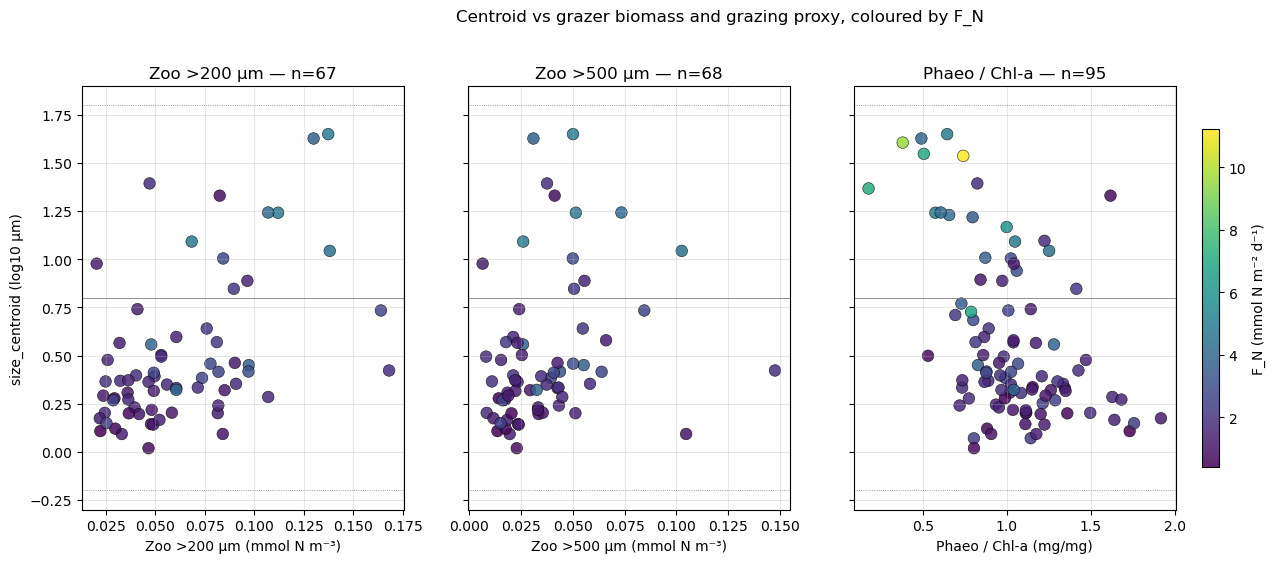

In [10]:
# --- Cell: Centroid vs (Zoo>200, Zoo>500, PhaeoChl), coloured by F_N ---
import numpy as np
import matplotlib.pyplot as plt

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)

panels = [
    ("zoo_gt200_mmolN", "Zoo >200 µm (mmol N m⁻³)"),
    ("zoo_gt500_mmolN", "Zoo >500 µm (mmol N m⁻³)"),
    ("PhaeoChl_ratio", "Phaeo / Chl-a (mg/mg)"),
]

# Shared F_N colour limits across panels
fn_mask = df["FN_mmolN_m2_d"].notna() & df["size_centroid"].notna()
fn_vmin, fn_vmax = (df.loc[fn_mask, "FN_mmolN_m2_d"].min(),
                    df.loc[fn_mask, "FN_mmolN_m2_d"].max())

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, (xcol, xlabel) in zip(axes, panels):
    m = (df[xcol].notna()
         & df["size_centroid"].notna()
         & df["FN_mmolN_m2_d"].notna())
    sc = ax.scatter(df.loc[m, xcol],
                    df.loc[m, "size_centroid"],
                    c=df.loc[m, "FN_mmolN_m2_d"],
                    cmap="viridis",
                    vmin=fn_vmin, vmax=fn_vmax,
                    s=70, edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_title(f"{xlabel.split(' (')[0]} — n={m.sum()}")
    ax.grid(alpha=0.3)
    for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                       (NANO_LOG, "Nano", "-"),
                       (MICRO_LOG, "Micro", ":")]:
        ax.axhline(y, color="gray", lw=0.6, ls=ls)

axes[0].set_ylabel("size_centroid (log10 µm)")
fig.suptitle("Centroid vs grazer biomass and grazing proxy, coloured by F_N",
             y=1.02)
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("F_N (mmol N m⁻² d⁻¹)")
plt.show()

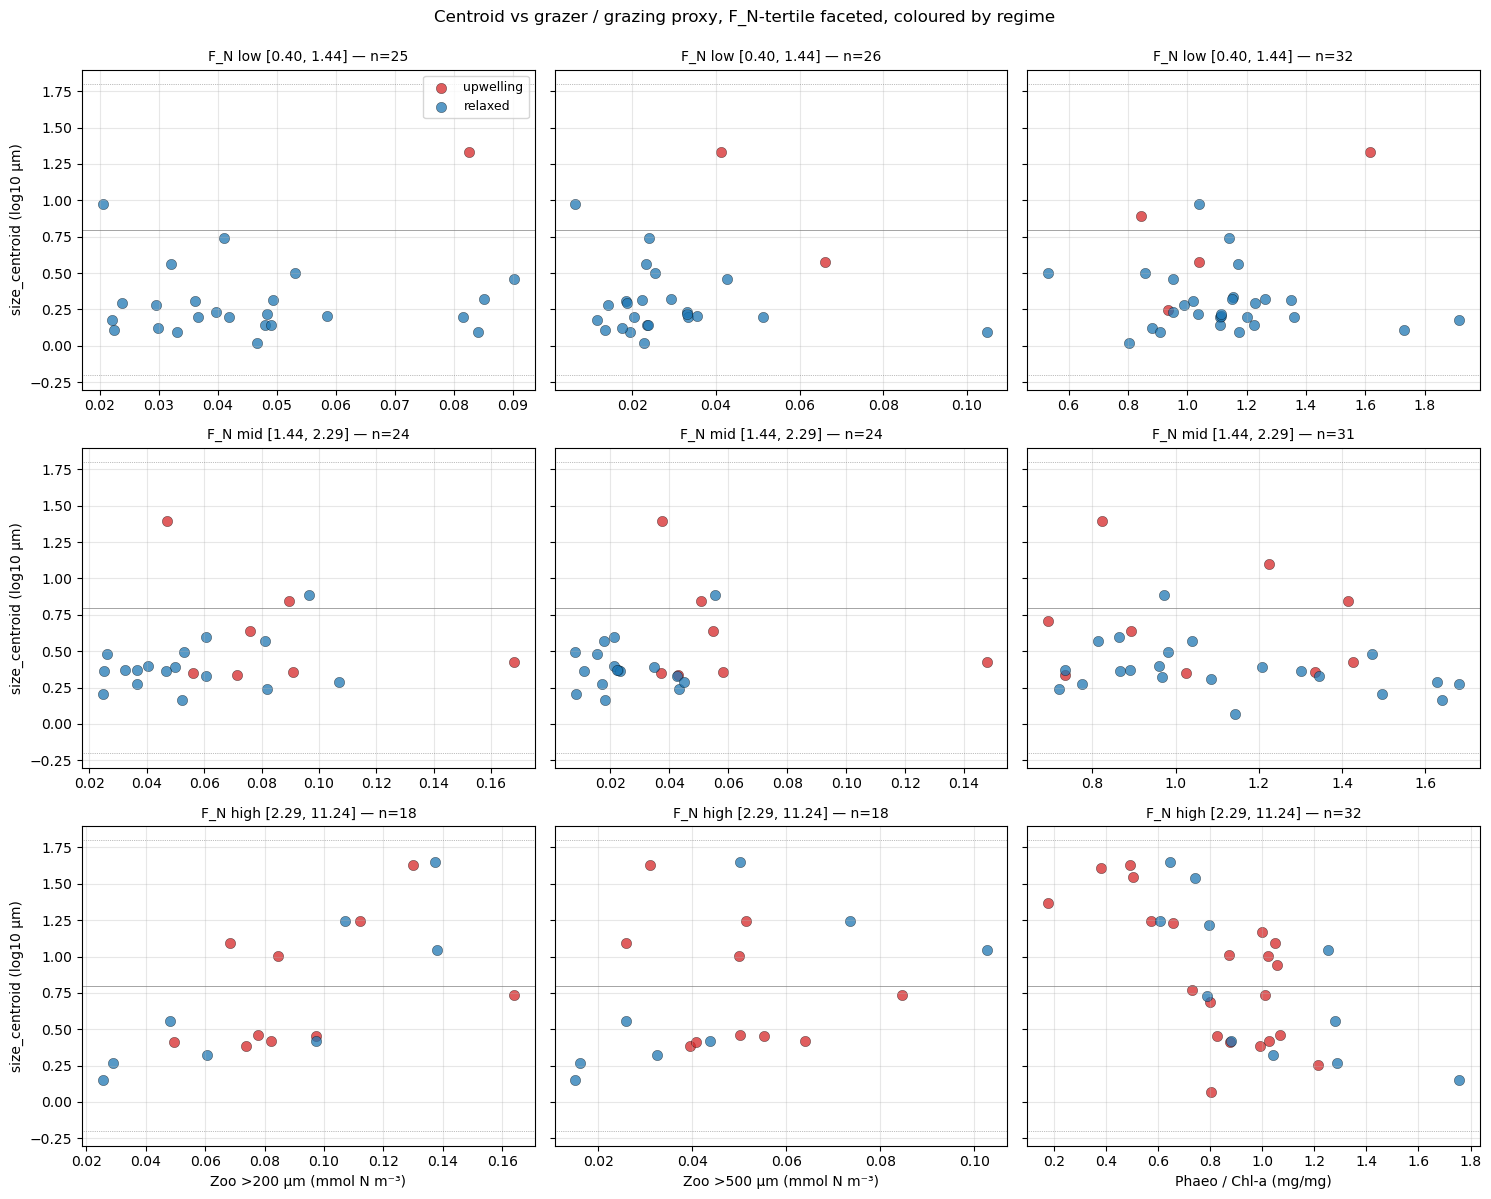

In [11]:
# --- Cell: F_N-tertile facets of centroid vs grazer axes ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
REGIME_COLORS = {"upwelling": "#d62728", "relaxed": "#1f77b4"}

# Tertile edges defined on F_N where centroid is also present
base_mask = df["FN_mmolN_m2_d"].notna() & df["size_centroid"].notna()
edges = np.quantile(df.loc[base_mask, "FN_mmolN_m2_d"], [0, 1/3, 2/3, 1.0])
TIERS = ["low", "mid", "high"]

dfp = df.copy()
dfp["fn_tertile"] = pd.cut(dfp["FN_mmolN_m2_d"], bins=edges,
                            include_lowest=True, labels=TIERS)

panels = [
    ("zoo_gt200_mmolN", "Zoo >200 µm (mmol N m⁻³)"),
    ("zoo_gt500_mmolN", "Zoo >500 µm (mmol N m⁻³)"),
    ("PhaeoChl_ratio", "Phaeo / Chl-a (mg/mg)"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
for row, tier in enumerate(TIERS):
    lo, hi = edges[row], edges[row + 1]
    for col, (xcol, xlabel) in enumerate(panels):
        ax = axes[row, col]
        for reg, c in REGIME_COLORS.items():
            m = (dfp["fn_tertile"] == tier) & dfp[xcol].notna() \
                & dfp["size_centroid"].notna() & (dfp["upwelling"] == reg)
            ax.scatter(dfp.loc[m, xcol], dfp.loc[m, "size_centroid"],
                       c=c, s=55, edgecolor="black", linewidth=0.3, alpha=0.75,
                       label=reg if (row == 0 and col == 0) else None)
        for y, ls in [(PICO_LOG, ":"), (NANO_LOG, "-"), (MICRO_LOG, ":")]:
            ax.axhline(y, color="gray", lw=0.5, ls=ls)
        n_panel = ((dfp["fn_tertile"] == tier) & dfp[xcol].notna()
                   & dfp["size_centroid"].notna()).sum()
        ax.set_title(f"F_N {tier} [{lo:.2f}, {hi:.2f}] — n={n_panel}",
                     fontsize=10)
        ax.grid(alpha=0.3)
        if row == 2:
            ax.set_xlabel(xlabel)
        if col == 0:
            ax.set_ylabel("size_centroid (log10 µm)")

axes[0, 0].legend(loc="best", fontsize=9)
fig.suptitle("Centroid vs grazer / grazing proxy, F_N-tertile faceted, coloured by regime",
             y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# --- Cell: Spearman partial correlation, centroid × grazer controlling for F_N ---
import numpy as np
import pandas as pd
from scipy import stats

def partial_spearman(x, y, z):
    """Spearman partial correlation of x and y, controlling for z.
    Standard partial-correlation formula on pairwise Spearman ρ."""
    m = pd.notna(x) & pd.notna(y) & pd.notna(z)
    x_, y_, z_ = x[m], y[m], z[m]
    if len(x_) < 3:
        return np.nan, len(x_)
    rxy, _ = stats.spearmanr(x_, y_)
    rxz, _ = stats.spearmanr(x_, z_)
    ryz, _ = stats.spearmanr(y_, z_)
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz**2) * (1 - ryz**2)), len(x_)

print(f"{'variable':22s} {'ρ_raw':>8s} {'n_raw':>6s}   "
      f"{'ρ | F_N':>9s} {'n_part':>7s}   {'Δρ':>7s}")
print("-" * 70)
for v in ["zoo_gt200_mmolN", "zoo_gt500_mmolN", "PhaeoChl_ratio"]:
    m_raw = df[v].notna() & df["size_centroid"].notna()
    raw, _ = stats.spearmanr(df.loc[m_raw, v], df.loc[m_raw, "size_centroid"])
    part, n_part = partial_spearman(df[v], df["size_centroid"], df["FN_mmolN_m2_d"])
    print(f"{v:22s} {raw:+8.3f} {m_raw.sum():>6d}   "
          f"{part:+9.3f} {n_part:>7d}   {part-raw:+7.3f}")

variable                  ρ_raw  n_raw     ρ | F_N  n_part        Δρ
----------------------------------------------------------------------
zoo_gt200_mmolN          +0.388     73      +0.292      67    -0.096
zoo_gt500_mmolN          +0.289     74      +0.236      68    -0.052
PhaeoChl_ratio           -0.461    103      -0.295      95    +0.166


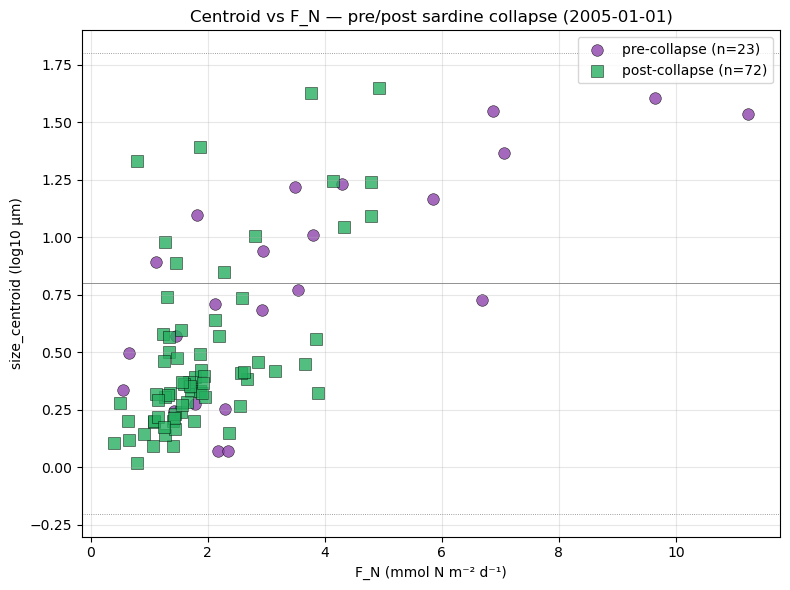

In [13]:
# --- Cell: Centroid vs F_N, coloured by pre/post sardine collapse ---
import numpy as np
import matplotlib.pyplot as plt

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
ERA_CUTOFF = "2005-01-01"

era = np.where(df["_date"] < ERA_CUTOFF, "pre-collapse", "post-collapse")
m_all = df["FN_mmolN_m2_d"].notna() & df["size_centroid"].notna()

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, marker in [("pre-collapse",  "#8e44ad", "o"),
                              ("post-collapse", "#27ae60", "s")]:
    m = m_all & (era == label)
    ax.scatter(df.loc[m, "FN_mmolN_m2_d"],
               df.loc[m, "size_centroid"],
               c=color, label=f"{label} (n={m.sum()})",
               s=70, edgecolor="black", linewidth=0.4, alpha=0.8, marker=marker)
for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    ax.axhline(y, color="gray", lw=0.6, ls=ls)
ax.set_xlabel("F_N (mmol N m⁻² d⁻¹)")
ax.set_ylabel("size_centroid (log10 µm)")
ax.set_title(f"Centroid vs F_N — pre/post sardine collapse ({ERA_CUTOFF})")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

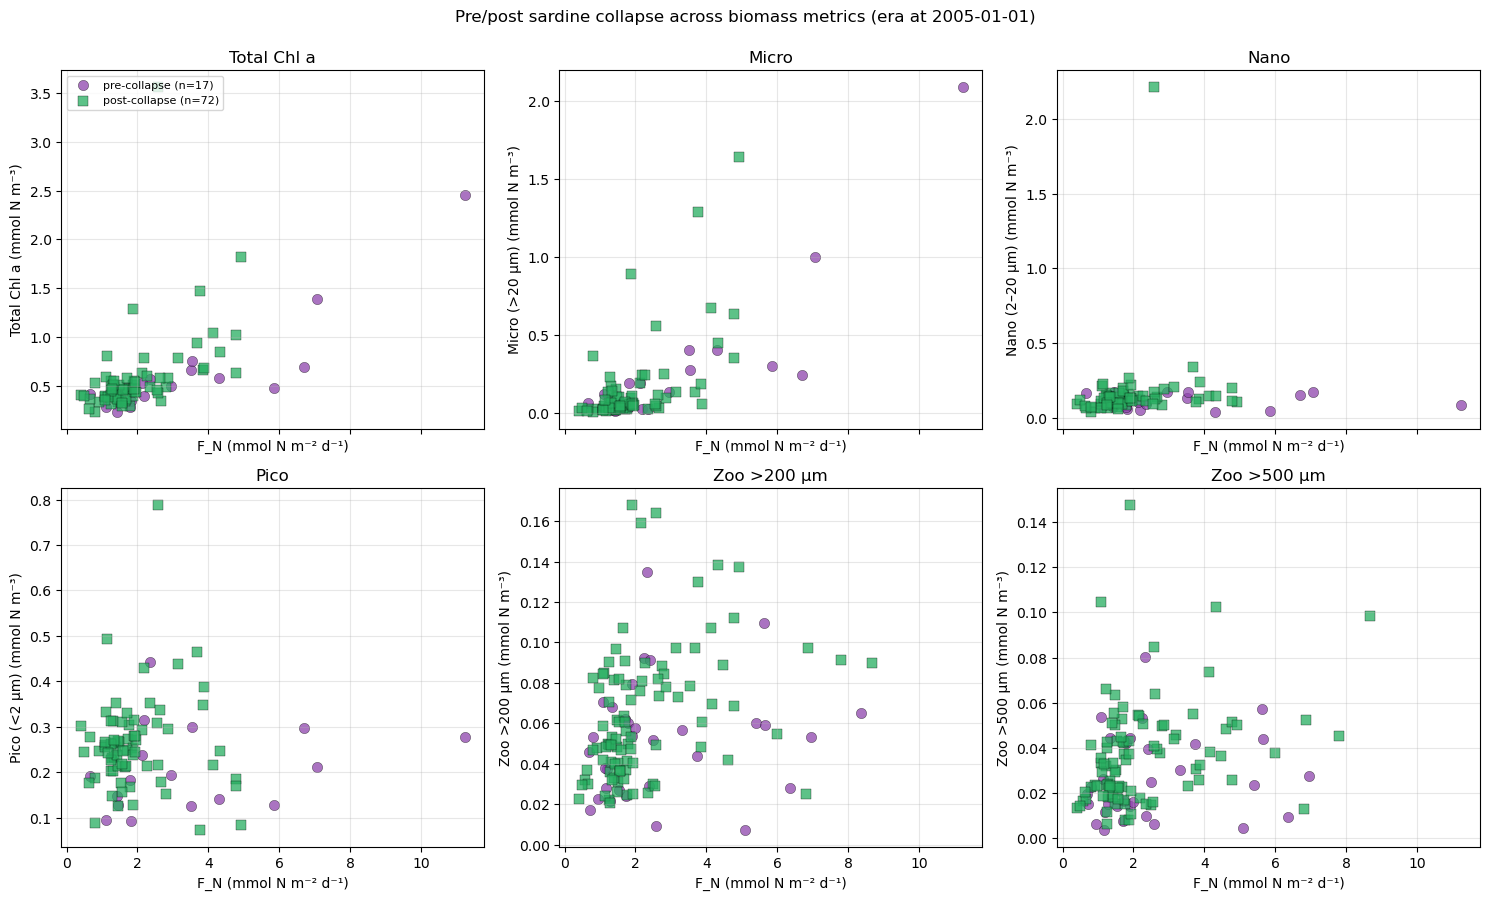

In [14]:
# --- Cell: Pre/post sardine collapse across biomass metrics ---
import numpy as np
import matplotlib.pyplot as plt

ERA_CUTOFF = "2005-01-01"
ERA_COLORS = {"pre-collapse": "#8e44ad", "post-collapse": "#27ae60"}
ERA_MARKERS = {"pre-collapse": "o", "post-collapse": "s"}

era = np.where(df["_date"] < ERA_CUTOFF, "pre-collapse", "post-collapse")

panels = [
    ("TotChlA_mmolN",   "Total Chl a (mmol N m⁻³)"),
    ("micro_mmolN",     "Micro (>20 µm) (mmol N m⁻³)"),
    ("nano_mmolN",      "Nano (2–20 µm) (mmol N m⁻³)"),
    ("pico_mmolN",      "Pico (<2 µm) (mmol N m⁻³)"),
    ("zoo_gt200_mmolN", "Zoo >200 µm (mmol N m⁻³)"),
    ("zoo_gt500_mmolN", "Zoo >500 µm (mmol N m⁻³)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
for ax, (ycol, ylabel) in zip(axes.flat, panels):
    for label, color in ERA_COLORS.items():
        m = (df["FN_mmolN_m2_d"].notna()
             & df[ycol].notna()
             & (era == label))
        ax.scatter(df.loc[m, "FN_mmolN_m2_d"],
                   df.loc[m, ycol],
                   c=color,
                   marker=ERA_MARKERS[label],
                   label=f"{label} (n={m.sum()})",
                   s=55, edgecolor="black", linewidth=0.3, alpha=0.75)
    ax.set_xlabel("F_N (mmol N m⁻² d⁻¹)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(" (")[0])
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Pre/post sardine collapse across biomass metrics (era at 2005-01-01)",
             y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_47953/2573031114.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{u}\nn={counts[u]}" for u in UI_ORDER])


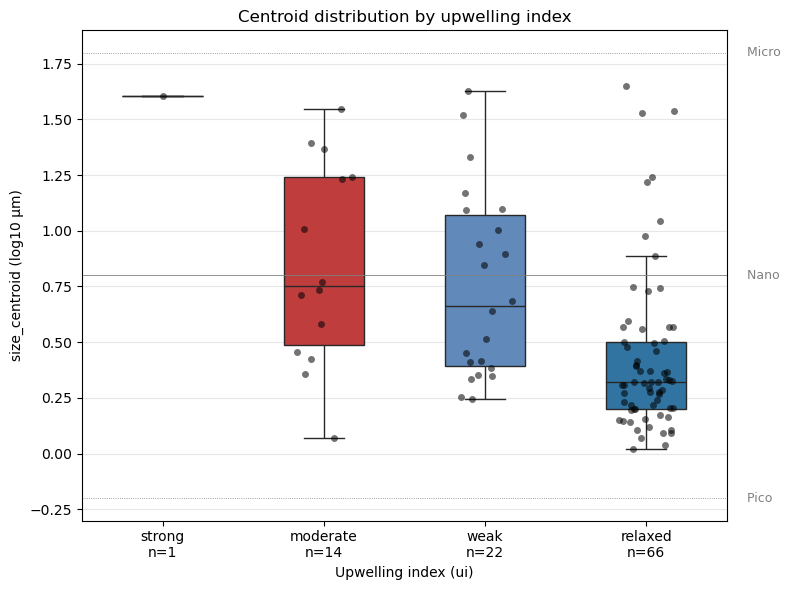

Top 8 relaxed-regime months by centroid:
      date  temp_50m  Isotherm_21  size_centroid  FN_mmolN_m2_d  Chl_niskin_mmolN
2012-01-01 22.373061         87.0       1.650439       4.924833          1.916887
1997-01-01 22.208000         64.0       1.537624      11.237424          2.605573
2011-01-01 23.633924        114.0       1.530237            NaN          1.855139
2009-01-01 23.378931         80.0       1.243323       4.141562          1.039845
1996-11-01 23.308000        103.0       1.218832       3.498725          0.718972
2014-06-01 22.548770        115.0       1.044018       4.336396          0.207212
2016-12-01 25.534859        109.0       0.977632       1.267776          0.258121
2008-01-01 23.126061         83.0       0.888342       1.456200          0.226803


In [15]:
# --- Cell: Centroid distribution across upwelling index (ui) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
UI_ORDER = ["strong", "moderate", "weak", "relaxed"]
UI_PALETTE = {"strong": "#7b0a0a", "moderate": "#d62728",
              "weak":   "#5288c8", "relaxed":  "#1f77b4"}

m = df["size_centroid"].notna() & df["ui"].notna()
plot_df = df.loc[m].copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=plot_df, x="ui", y="size_centroid", order=UI_ORDER,
            palette=UI_PALETTE, width=0.5, fliersize=0, ax=ax)
sns.stripplot(data=plot_df, x="ui", y="size_centroid", order=UI_ORDER,
              color="black", size=5, alpha=0.55, jitter=0.18, ax=ax)

for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    ax.axhline(y, color="gray", lw=0.6, ls=ls)
    ax.text(len(UI_ORDER) - 0.4, y, f" {lbl}",
            va="center", fontsize=9, color="gray")

counts = plot_df["ui"].value_counts().reindex(UI_ORDER).fillna(0).astype(int)
ax.set_xticklabels([f"{u}\nn={counts[u]}" for u in UI_ORDER])
ax.set_xlabel("Upwelling index (ui)")
ax.set_ylabel("size_centroid (log10 µm)")
ax.set_title("Centroid distribution by upwelling index")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Top-N relaxed-regime months by centroid — candidates for the outlier check
relaxed_top = (plot_df[plot_df["ui"] == "relaxed"]
               .nlargest(8, "size_centroid")
               [["date", "temp_50m", "Isotherm_21", "size_centroid",
                 "FN_mmolN_m2_d", "Chl_niskin_mmolN"]])
print("Top 8 relaxed-regime months by centroid:")
print(relaxed_top.to_string(index=False))

In [16]:
# --- Cell 1: Top relaxed high-centroid months + preceding-month regime + context ---
import numpy as np
import pandas as pd

df_sorted = df.sort_values("_date").reset_index(drop=True)
m = (df_sorted["ui"] == "relaxed") & df_sorted["size_centroid"].notna()
top_n = df_sorted.loc[m].nlargest(10, "size_centroid")

records = []
for _, row in top_n.iterrows():
    i = df_sorted.index[df_sorted["_date"] == row["_date"]][0]
    rec = {
        "date":       row["_date"].strftime("%Y-%m"),
        "centroid":   round(row["size_centroid"], 2),
        "F_N":        round(row["FN_mmolN_m2_d"], 2)  if pd.notna(row["FN_mmolN_m2_d"]) else None,
        "Chl_niskin": round(row["Chl_niskin_mmolN"], 2) if pd.notna(row["Chl_niskin_mmolN"]) else None,
        "Phaeo/Chl":  round(row["PhaeoChl_ratio"], 2)   if pd.notna(row["PhaeoChl_ratio"]) else None,
        "ui(t)":      row["ui"],
        "T50(t)":     round(row["temp_50m"], 1)         if pd.notna(row["temp_50m"]) else None,
    }
    for lag in (1, 2, 3):
        if i - lag >= 0:
            p = df_sorted.iloc[i - lag]
            rec[f"ui(t-{lag})"] = p["ui"] if pd.notna(p["ui"]) else "—"
            rec[f"T50(t-{lag})"] = round(p["temp_50m"], 1) if pd.notna(p["temp_50m"]) else None
        else:
            rec[f"ui(t-{lag})"] = None
            rec[f"T50(t-{lag})"] = None
    records.append(rec)

print("Top 10 relaxed-regime months by centroid, with preceding-month regime context:")
print(pd.DataFrame(records).to_string(index=False))

Top 10 relaxed-regime months by centroid, with preceding-month regime context:
   date  centroid   F_N  Chl_niskin  Phaeo/Chl   ui(t)  T50(t) ui(t-1)  T50(t-1)  ui(t-2)  T50(t-2)  ui(t-3)  T50(t-3)
2012-01      1.65  4.92        1.92       0.64 relaxed    22.4       —       NaN        —       NaN  relaxed      23.9
1997-01      1.54 11.24        2.61       0.74 relaxed    22.2 relaxed      24.4  relaxed      23.3  relaxed      23.0
2011-01      1.53   NaN        1.86       0.67 relaxed    23.6 relaxed      25.1  relaxed      26.9  relaxed      26.9
2009-01      1.24  4.14        1.04       0.61 relaxed    23.4 relaxed      24.9  relaxed      24.5  relaxed      25.3
1996-11      1.22  3.50        0.72       0.80 relaxed    23.3 relaxed      23.0  relaxed      23.6     weak      22.0
2014-06      1.04  4.34        0.21       1.25 relaxed    22.5  strong      19.9 moderate      20.9        —       NaN
2016-12      0.98  1.27        0.26       1.04 relaxed    25.5       —       NaN        

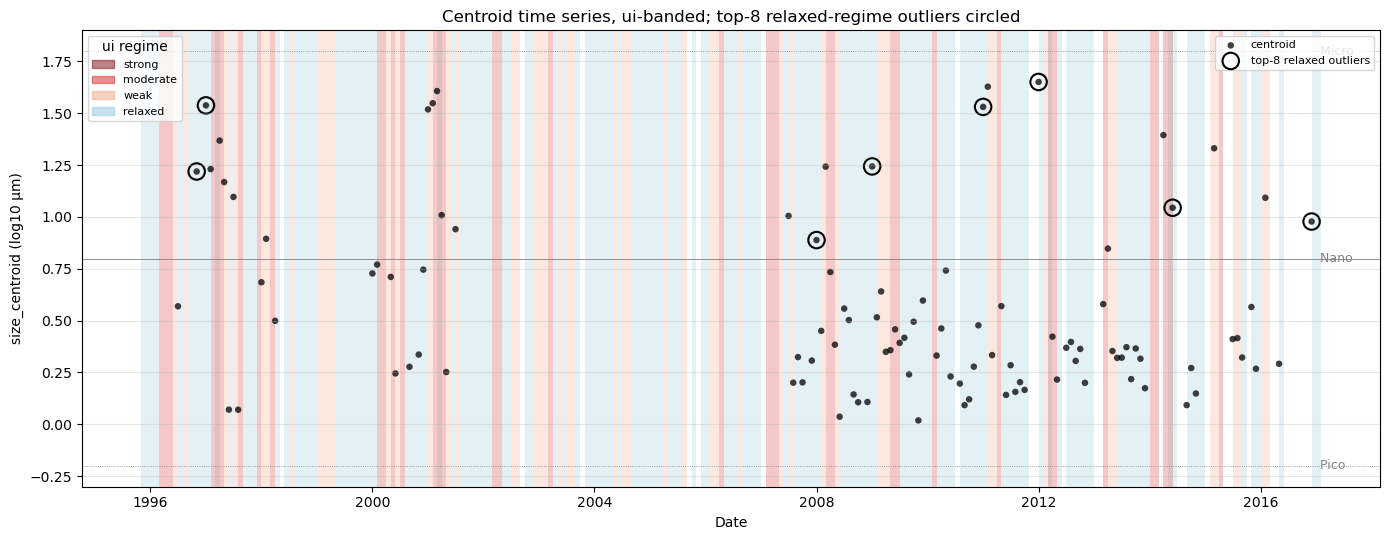

In [17]:
# --- Cell 2: Centroid time series with ui-regime background banding ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
UI_COLORS = {"strong":   "#7b0a0a",
             "moderate": "#d62728",
             "weak":     "#f4a582",
             "relaxed":  "#92c5de"}

df_sorted = df.sort_values("_date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5.5))
# Per-month ui background band
for _, row in df_sorted.iterrows():
    if pd.notna(row["ui"]):
        ax.axvspan(row["_date"],
                   row["_date"] + pd.DateOffset(months=1),
                   color=UI_COLORS[row["ui"]], alpha=0.25, lw=0)

# Centroid scatter
m = df_sorted["size_centroid"].notna()
ax.scatter(df_sorted.loc[m, "_date"], df_sorted.loc[m, "size_centroid"],
           c="black", s=22, alpha=0.75, edgecolor="none", label="centroid")

# Highlight top-8 relaxed outliers
m_relaxed = (df_sorted["ui"] == "relaxed") & df_sorted["size_centroid"].notna()
top_n = df_sorted.loc[m_relaxed].nlargest(8, "size_centroid")
ax.scatter(top_n["_date"], top_n["size_centroid"],
           facecolors="none", edgecolors="black", s=140, lw=1.5,
           label="top-8 relaxed outliers")

for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    ax.axhline(y, color="gray", lw=0.6, ls=ls)
    ax.text(df_sorted["_date"].max(), y, f" {lbl}",
            va="center", fontsize=9, color="gray")

ui_patches = [mpatches.Patch(color=UI_COLORS[u], alpha=0.5, label=u)
              for u in ["strong", "moderate", "weak", "relaxed"]]
leg1 = ax.legend(handles=ui_patches, loc="upper left",
                 title="ui regime", fontsize=8)
ax.add_artist(leg1)
ax.legend(loc="upper right", fontsize=8)

ax.set_xlabel("Date")
ax.set_ylabel("size_centroid (log10 µm)")
ax.set_title("Centroid time series, ui-banded; top-8 relaxed-regime outliers circled")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

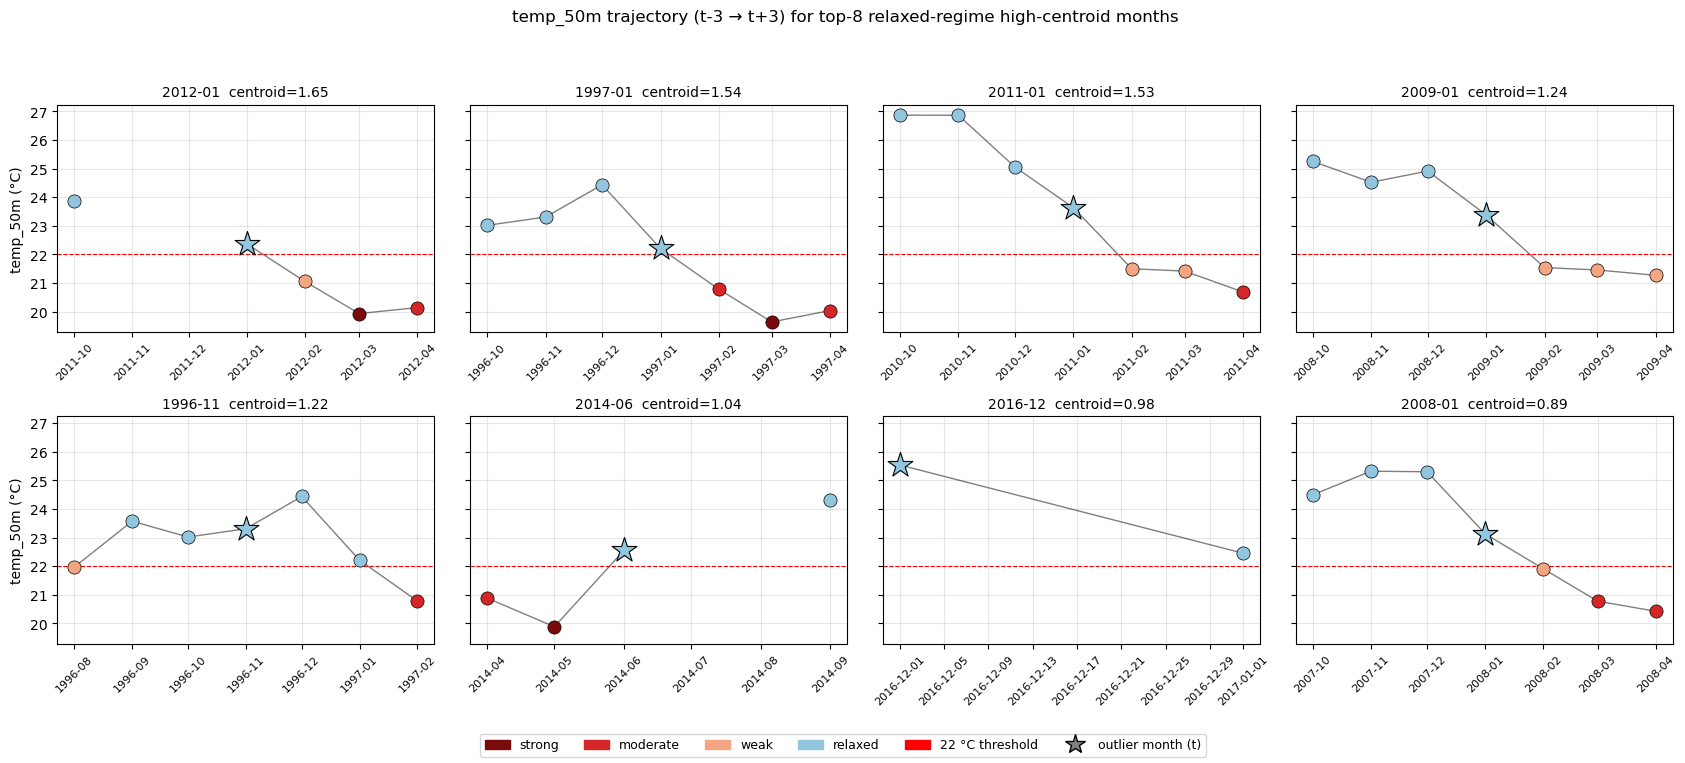

In [18]:
# --- Cell 3 (revised): Per-outlier temp_50m trajectories (t-3 → t+3) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

UI_COLORS = {"strong":   "#7b0a0a",
             "moderate": "#d62728",
             "weak":     "#f4a582",
             "relaxed":  "#92c5de"}

df_sorted = df.sort_values("_date").reset_index(drop=True)
m_relaxed = (df_sorted["ui"] == "relaxed") & df_sorted["size_centroid"].notna()
top_n = df_sorted.loc[m_relaxed].nlargest(8, "size_centroid")

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharey=True)
for ax, (_, row) in zip(axes.flat, top_n.iterrows()):
    i = df_sorted.index[df_sorted["_date"] == row["_date"]][0]
    lo = max(0, i - 3)
    hi = min(len(df_sorted), i + 4)  # +4 because slice end is exclusive
    seg = df_sorted.iloc[lo:hi]

    ax.plot(seg["_date"], seg["temp_50m"], "k-", lw=1, alpha=0.5)

    # Per-month markers — star for outlier month, circle for context months
    for _, sr in seg.iterrows():
        c = UI_COLORS.get(sr["ui"], "lightgray")
        if sr["_date"] == row["_date"]:
            ax.scatter(sr["_date"], sr["temp_50m"], c=c, marker="*",
                       s=350, edgecolor="black", linewidth=0.8, zorder=4)
        else:
            ax.scatter(sr["_date"], sr["temp_50m"], c=c, s=90,
                       edgecolor="black", linewidth=0.5, zorder=3)

    ax.axhline(22.0, color="red", ls="--", lw=0.8)
    ax.set_title(f"{row['_date'].strftime('%Y-%m')}  "
                 f"centroid={row['size_centroid']:.2f}", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel("temp_50m (°C)")

ui_patches = [mpatches.Patch(color=UI_COLORS[u], label=u)
              for u in ["strong", "moderate", "weak", "relaxed"]]
ui_patches.append(mpatches.Patch(color="red", label="22 °C threshold"))
star_handle = plt.Line2D([0], [0], marker="*", color="w",
                          markerfacecolor="gray", markeredgecolor="black",
                          markersize=15, label="outlier month (t)")
ui_patches.append(star_handle)

fig.legend(handles=ui_patches, loc="lower center", ncol=6, fontsize=9)
fig.suptitle("temp_50m trajectory (t-3 → t+3) for top-8 relaxed-regime high-centroid months",
             y=1.00, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

# NO PICO DOMINANCE???

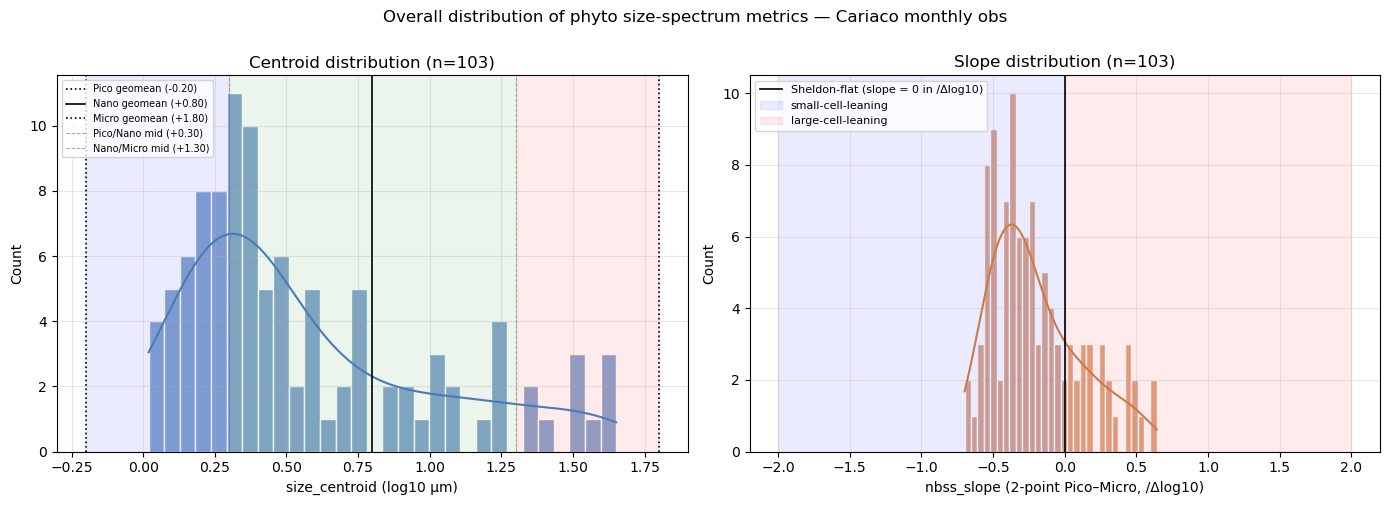

In [19]:
# --- Cell 1: Overall distribution of centroid and slope ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
PICO_NANO_MID  = (PICO_LOG + NANO_LOG) / 2     # +0.30
NANO_MICRO_MID = (NANO_LOG + MICRO_LOG) / 2    # +1.30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Centroid distribution
ax = axes[0]
sns.histplot(df["size_centroid"].dropna(), bins=30, kde=True, ax=ax,
             color="#4a7ab8", alpha=0.65, edgecolor="white")
ax.axvspan(PICO_LOG, PICO_NANO_MID,  alpha=0.08, color="blue")
ax.axvspan(PICO_NANO_MID, NANO_MICRO_MID, alpha=0.08, color="green")
ax.axvspan(NANO_MICRO_MID, MICRO_LOG, alpha=0.08, color="red")
for x, lbl, ls in [(PICO_LOG,  f"Pico geomean ({PICO_LOG:+.2f})", ":"),
                   (NANO_LOG,  f"Nano geomean ({NANO_LOG:+.2f})", "-"),
                   (MICRO_LOG, f"Micro geomean ({MICRO_LOG:+.2f})", ":")]:
    ax.axvline(x, color="black", ls=ls, lw=1.2, label=lbl)
ax.axvline(PICO_NANO_MID, color="gray", ls="--", lw=0.7, alpha=0.7,
           label=f"Pico/Nano mid ({PICO_NANO_MID:+.2f})")
ax.axvline(NANO_MICRO_MID, color="gray", ls="--", lw=0.7, alpha=0.7,
           label=f"Nano/Micro mid ({NANO_MICRO_MID:+.2f})")
ax.set_xlabel("size_centroid (log10 µm)")
ax.set_ylabel("Count")
ax.set_title(f"Centroid distribution (n={df['size_centroid'].notna().sum()})")
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)

# Slope distribution
ax = axes[1]
sns.histplot(df["nbss_slope"].dropna(), bins=30, kde=True, ax=ax,
             color="#cc7a4a", alpha=0.65, edgecolor="white")
ax.axvline(0, color="black", ls="-", lw=1.2,
           label="Sheldon-flat (slope = 0 in /Δlog10)")
ax.axvspan(-2, 0, alpha=0.08, color="blue", label="small-cell-leaning")
ax.axvspan(0,  2, alpha=0.08, color="red",  label="large-cell-leaning")
ax.set_xlabel("nbss_slope (2-point Pico–Micro, /Δlog10)")
ax.set_ylabel("Count")
ax.set_title(f"Slope distribution (n={df['nbss_slope'].notna().sum()})")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

fig.suptitle("Overall distribution of phyto size-spectrum metrics — Cariaco monthly obs",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# --- Cell 2: Direct Pico-dominance counts under different definitions ---
import pandas as pd
import numpy as np

mask = df[["pico_mmolN", "nano_mmolN", "micro_mmolN"]].notna().all(axis=1)
phyto = df.loc[mask, ["pico_mmolN", "nano_mmolN", "micro_mmolN"]]
total = phyto.sum(axis=1)
pico_frac  = phyto["pico_mmolN"]  / total
nano_frac  = phyto["nano_mmolN"]  / total
micro_frac = phyto["micro_mmolN"] / total

n_full = len(phyto)
n_centroid = df["size_centroid"].notna().sum()

defs = [
    ("pico_frac > 0.50 (Pico majority)",                (pico_frac > 0.50).sum(), n_full),
    ("pico_frac > 0.40",                                (pico_frac > 0.40).sum(), n_full),
    ("pico_frac > 0.33 (over uniform third)",           (pico_frac > 0.33).sum(), n_full),
    ("pico is the LARGEST bin",                        ((pico_frac > nano_frac) & (pico_frac > micro_frac)).sum(), n_full),
    ("centroid < +0.30 (closer to Pico than Nano)",     (df["size_centroid"] < 0.30).sum(), n_centroid),
    ("centroid < 0.00",                                 (df["size_centroid"] < 0.0).sum(), n_centroid),
    ("centroid < -0.10 (strongly Pico-leaning)",        (df["size_centroid"] < -0.10).sum(), n_centroid),
    ("nbss_slope < 0 (small-cell-leaning)",             (df["nbss_slope"] < 0).sum(), df["nbss_slope"].notna().sum()),
    ("nbss_slope < -0.25",                              (df["nbss_slope"] < -0.25).sum(), df["nbss_slope"].notna().sum()),
]

print(f"Pico-dominance under various definitions:")
print(f"{'definition':52s} {'count':>6s}  {'denom':>6s}  {'%':>5s}")
print("-" * 76)
for name, count, denom in defs:
    pct = 100 * count / denom if denom else 0
    print(f"{name:52s} {count:>6d}  {denom:>6d}  {pct:>5.1f}")

# Most Pico-leaning months — full row context
out = df.loc[mask, ["date", "upwelling", "ui", "temp_50m",
                    "pico_mmolN", "nano_mmolN", "micro_mmolN",
                    "size_centroid", "nbss_slope"]].copy()
out["pico_frac"]  = pico_frac.values
out["nano_frac"]  = nano_frac.values
out["micro_frac"] = micro_frac.values
print(f"\nTop 8 most Pico-leaning months by pico_frac:")
print(out.nlargest(8, "pico_frac")[
    ["date", "upwelling", "ui", "pico_frac", "nano_frac", "micro_frac",
     "size_centroid", "nbss_slope"]
].to_string(index=False))

Pico-dominance under various definitions:
definition                                            count   denom      %
----------------------------------------------------------------------------
pico_frac > 0.50 (Pico majority)                         59      95   62.1
pico_frac > 0.40                                         71      95   74.7
pico_frac > 0.33 (over uniform third)                    77      95   81.1
pico is the LARGEST bin                                  73      95   76.8
centroid < +0.30 (closer to Pico than Nano)              32     103   31.1
centroid < 0.00                                           0     103    0.0
centroid < -0.10 (strongly Pico-leaning)                  0     103    0.0
nbss_slope < 0 (small-cell-leaning)                      78     103   75.7
nbss_slope < -0.25                                       55     103   53.4

Top 8 most Pico-leaning months by pico_frac:
      date upwelling       ui  pico_frac  nano_frac  micro_frac  size_centroid  nbss_

# OVERVIEW PLOTSSSSS

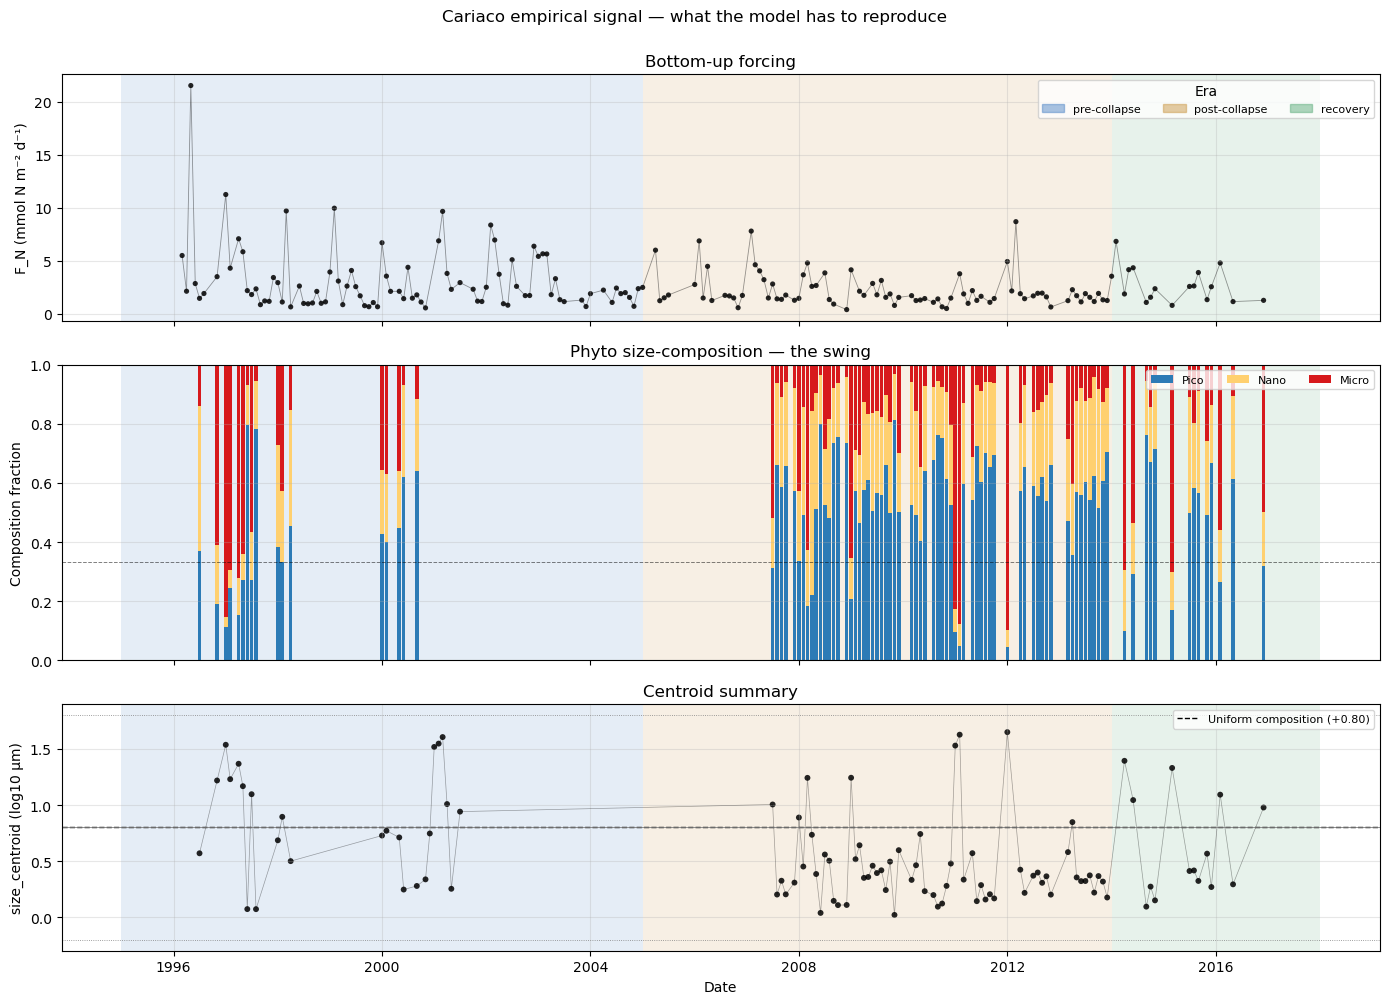

In [21]:
# --- Cell 2: Multi-panel empirical signal — F_N, composition, centroid ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
UNIFORM_REF = +0.80

ERA_BOUNDS = [
    ("pre-collapse",  pd.Timestamp("1995-01-01"), pd.Timestamp("2005-01-01"), "#5288c8"),
    ("post-collapse", pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01"), "#cc9a4a"),
    ("recovery",      pd.Timestamp("2014-01-01"), pd.Timestamp("2018-01-01"), "#5fae7e"),
]

df_s = df.sort_values("_date").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={"height_ratios": [1.0, 1.2, 1.0]})

# Era shading on all panels
for ax in axes:
    for _, start, end, color in ERA_BOUNDS:
        ax.axvspan(start, end, alpha=0.15, color=color, lw=0)

# Panel 1: F_N
ax = axes[0]
m = df_s["FN_mmolN_m2_d"].notna()
ax.plot(df_s.loc[m, "_date"], df_s.loc[m, "FN_mmolN_m2_d"],
        color="black", lw=0.6, alpha=0.4)
ax.scatter(df_s.loc[m, "_date"], df_s.loc[m, "FN_mmolN_m2_d"],
           c="black", s=14, alpha=0.85, edgecolor="none")
ax.set_ylabel("F_N (mmol N m⁻² d⁻¹)")
ax.set_title("Bottom-up forcing")
ax.grid(alpha=0.3)
era_patches = [mpatches.Patch(color=c, alpha=0.5, label=name)
               for name, _, _, c in ERA_BOUNDS]
ax.legend(handles=era_patches, loc="upper right", fontsize=8, ncol=3, title="Era")

# Panel 2: stacked composition
ax = axes[1]
m_c = (df_s["pico_mmolN"].notna()
       & df_s["nano_mmolN"].notna()
       & df_s["micro_mmolN"].notna())
sub = df_s.loc[m_c].copy()
total = sub[["pico_mmolN", "nano_mmolN", "micro_mmolN"]].sum(axis=1)
pico_f  = sub["pico_mmolN"]  / total
nano_f  = sub["nano_mmolN"]  / total
micro_f = sub["micro_mmolN"] / total
ax.bar(sub["_date"], pico_f, width=25, color="#2c7bb6", label="Pico", edgecolor="none")
ax.bar(sub["_date"], nano_f, bottom=pico_f, width=25,
       color="#ffd06f", label="Nano", edgecolor="none")
ax.bar(sub["_date"], micro_f, bottom=pico_f + nano_f, width=25,
       color="#d7191c", label="Micro", edgecolor="none")
ax.axhline(1/3, color="black", ls="--", lw=0.7, alpha=0.5)
ax.set_ylabel("Composition fraction")
ax.set_ylim(0, 1)
ax.set_title("Phyto size-composition — the swing")
ax.legend(loc="upper right", fontsize=8, ncol=3)
ax.grid(alpha=0.3, axis="y")

# Panel 3: centroid
ax = axes[2]
m_cc = df_s["size_centroid"].notna()
ax.plot(df_s.loc[m_cc, "_date"], df_s.loc[m_cc, "size_centroid"],
        color="black", lw=0.5, alpha=0.35)
ax.scatter(df_s.loc[m_cc, "_date"], df_s.loc[m_cc, "size_centroid"],
           c="black", s=18, alpha=0.85, edgecolor="none")
ax.axhline(UNIFORM_REF, color="black", ls="--", lw=1,
           label=f"Uniform composition ({UNIFORM_REF:+.2f})")
for y, lbl, ls in [(PICO_LOG, "Pico", ":"),
                   (NANO_LOG, "Nano", "-"),
                   (MICRO_LOG, "Micro", ":")]:
    ax.axhline(y, color="gray", lw=0.6, ls=ls)
ax.set_ylabel("size_centroid (log10 µm)")
ax.set_xlabel("Date")
ax.set_title("Centroid summary")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Cariaco empirical signal — what the model has to reproduce",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_47953/2614688147.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{e}\nn={counts[e]}" for e in ERA_ORDER])


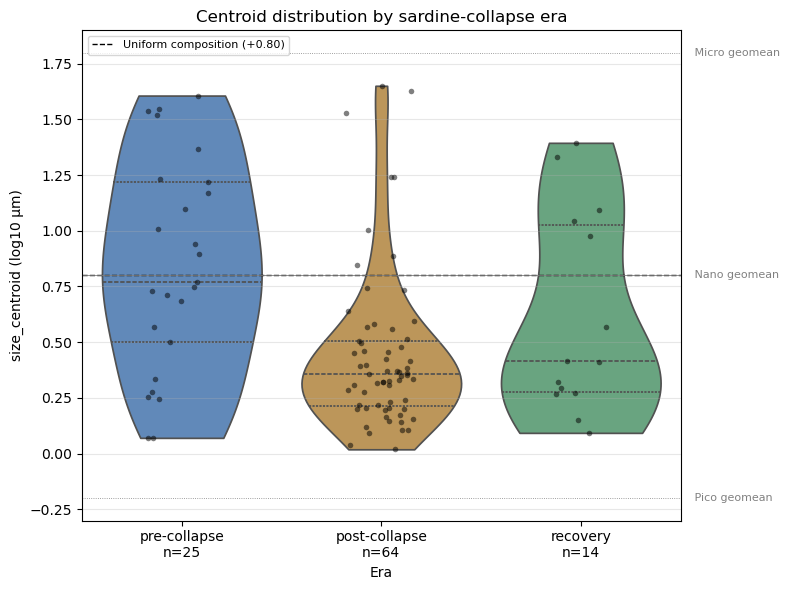


Centroid summary by era:
era                 n     mean   median                     IQR  range
pre-collapse       25   +0.844   +0.770  [+0.499, +1.219]  [+0.070, +1.606]
post-collapse      64   +0.448   +0.356  [+0.213, +0.506]  [+0.019, +1.650]
recovery           14   +0.616   +0.413  [+0.277, +1.027]  [+0.093, +1.394]


In [22]:
# --- Cell 1: 3-tier era split — centroid distribution ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PICO_LOG, NANO_LOG, MICRO_LOG = np.log10(0.63), np.log10(6.3), np.log10(63)
UNIFORM_REF = +0.80

def assign_era(d):
    if d < pd.Timestamp("2005-01-01"): return "pre-collapse"
    if d < pd.Timestamp("2014-01-01"): return "post-collapse"
    return "recovery"

df_p = df.copy()
df_p["era"] = df_p["_date"].apply(assign_era)
ERA_ORDER = ["pre-collapse", "post-collapse", "recovery"]
ERA_COLORS = {"pre-collapse":  "#5288c8",
              "post-collapse": "#cc9a4a",
              "recovery":      "#5fae7e"}

sub = df_p.loc[df_p["size_centroid"].notna()]
counts = sub["era"].value_counts().reindex(ERA_ORDER).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=sub, x="era", y="size_centroid", order=ERA_ORDER,
               palette=ERA_COLORS, inner="quartile", cut=0, ax=ax)
sns.stripplot(data=sub, x="era", y="size_centroid", order=ERA_ORDER,
              color="black", size=4, alpha=0.5, jitter=0.18, ax=ax)

ax.axhline(UNIFORM_REF, color="black", ls="--", lw=1.0,
           label=f"Uniform composition ({UNIFORM_REF:+.2f})")
for y, lbl, ls in [(PICO_LOG, "Pico geomean", ":"),
                   (NANO_LOG, "Nano geomean", "-"),
                   (MICRO_LOG, "Micro geomean", ":")]:
    ax.axhline(y, color="gray", lw=0.6, ls=ls)
    ax.text(2.55, y, f" {lbl}", va="center", fontsize=8, color="gray")

ax.set_xticklabels([f"{e}\nn={counts[e]}" for e in ERA_ORDER])
ax.set_xlabel("Era")
ax.set_ylabel("size_centroid (log10 µm)")
ax.set_title("Centroid distribution by sardine-collapse era")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"\nCentroid summary by era:")
print(f"{'era':16s} {'n':>4s} {'mean':>8s} {'median':>8s}  {'IQR':>22s}  range")
for e in ERA_ORDER:
    s = sub.loc[sub["era"] == e, "size_centroid"]
    print(f"{e:16s} {len(s):>4d} {s.mean():>+8.3f} {s.median():>+8.3f}  "
          f"[{s.quantile(0.25):+.3f}, {s.quantile(0.75):+.3f}]  "
          f"[{s.min():+.3f}, {s.max():+.3f}]")

In [23]:
# --- Cell: Confound check — does the era centroid contrast survive regime/season control? ---
import numpy as np
import pandas as pd

def assign_era(d):
    if d < pd.Timestamp("2005-01-01"): return "pre-collapse"
    if d < pd.Timestamp("2014-01-01"): return "post-collapse"
    return "recovery"

dfp = df.copy()
dfp["era"] = dfp["_date"].apply(assign_era)
sub = dfp.loc[dfp["size_centroid"].notna()].copy()
ERA_ORDER = ["pre-collapse", "post-collapse", "recovery"]

# 1. Regime mix by era — does pre-collapse over-represent upwelling months?
print("=== Regime mix by era (counts) ===")
mix = (sub.assign(reg=sub["upwelling"].fillna("unclassified"))
          .pivot_table(index="reg", columns="era",
                       values="size_centroid", aggfunc="count")
          .reindex(columns=ERA_ORDER).fillna(0).astype(int))
print(mix.to_string())
print("\nAs % within each era:")
print((mix / mix.sum(axis=0) * 100).round(1).to_string())

# 2. Centroid stratified by regime × era — decisive check
print("\n=== Centroid by (regime × era) — does ordering persist within regime? ===")
print(f"{'regime':14s} {'era':16s} {'n':>4s} {'mean':>8s} {'median':>8s}  {'IQR':>22s}")
print("-" * 78)
for reg in ["upwelling", "relaxed"]:
    for e in ERA_ORDER:
        s = sub.loc[(sub["upwelling"] == reg) & (sub["era"] == e), "size_centroid"]
        if len(s):
            print(f"{reg:14s} {e:16s} {len(s):>4d} {s.mean():>+8.3f} {s.median():>+8.3f}  "
                  f"[{s.quantile(0.25):+.3f}, {s.quantile(0.75):+.3f}]")
        else:
            print(f"{reg:14s} {e:16s} {len(s):>4d}       —        —              —")

# 3. Seasonal (calendar-month) coverage by era — does pre over-sample bloom months?
print("\n=== Coverage by calendar month and era ===")
sub["m"] = sub["_date"].dt.month
season = (sub.pivot_table(index="m", columns="era",
                           values="size_centroid", aggfunc="count")
             .reindex(columns=ERA_ORDER).fillna(0).astype(int))
season.index.name = "cal-month"
print(season.to_string())

# 4. F_N distribution by era — quantifies the bottom-up forcing difference
print("\n=== F_N distribution by era ===")
m_fn = dfp["FN_mmolN_m2_d"].notna()
for e in ERA_ORDER:
    s = dfp.loc[m_fn & (dfp["era"] == e), "FN_mmolN_m2_d"]
    if len(s):
        print(f"  {e:16s} n={len(s):>3d}  mean={s.mean():+6.2f}  median={s.median():+6.2f}  "
              f"IQR=[{s.quantile(0.25):+5.2f}, {s.quantile(0.75):+5.2f}]")

=== Regime mix by era (counts) ===
era        pre-collapse  post-collapse  recovery
reg                                             
relaxed               9             48         9
upwelling            16             16         5

As % within each era:
era        pre-collapse  post-collapse  recovery
reg                                             
relaxed            36.0           75.0      64.3
upwelling          64.0           25.0      35.7

=== Centroid by (regime × era) — does ordering persist within regime? ===
regime         era                 n     mean   median                     IQR
------------------------------------------------------------------------------
upwelling      pre-collapse       16   +1.201   +1.284  [+1.066, +1.509]
upwelling      post-collapse      16   +0.927   +0.836  [+0.660, +1.051]
upwelling      recovery            5   +1.184   +1.397  [+0.754, +1.554]
relaxed        pre-collapse        9   +0.937   +0.793  [+0.688, +1.125]
relaxed        post-colla

In [25]:
df

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
250   NaN
251   NaN
252   NaN
253   NaN
254   NaN
Name: euphotic_depth_obs, Length: 255, dtype: float64